# IMPORTS
- Importing the main data files and libraries

In [1]:
# Import the 3 parquet files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import LogNorm
import random

dataa = "data_28_2026-04-13_steps=1000_a-b=1000-100"
dataa = "data_54_2026-04-23_steps=1000_a-b=900-100_Lied"
data_dir = f"./Data/{dataa}/"

timestamp = pd.read_parquet(data_dir + "timestamp.parquet")
agents = pd.read_parquet(data_dir + "agents.parquet")
graph = pd.read_parquet(data_dir + "graph.parquet")

# AGENTS

In [2]:
print(agents.info)

<bound method DataFrame.info of          step  agent_id   personality  opinion_0  opinion_1
0           0        -1          BASE   0.851747   0.978350
1           0        -2          BASE  -0.364601   0.589355
2           0        -3          LIAR  -0.654699   0.724936
3           0        -4          LIAR  -0.538399  -0.218495
4           0        -5          LIAR   0.249611  -0.039820
...       ...       ...           ...        ...        ...
1000995  1000       996          BASE   1.000000  -1.000000
1000996  1000       997          LIAR  -1.000000   1.000000
1000997  1000       998  FACT_CHECKER   1.000000   1.000000
1000998  1000       999          LIAR   0.840000  -1.000000
1000999  1000      1000          LIAR   1.000000   1.000000

[1001000 rows x 5 columns]>


In [3]:
def draw_agree(agreement):
    plt.figure(figsize=(7, 7))
    plt.plot(
        agreement["mean_abs"],
        agreement["mean_opinion"],
        color="navy"
    )
    plt.scatter(
        agreement["mean_abs"],
        agreement["mean_opinion"],
        s=20,
        color="navy"
    )
    
    plt.scatter(
        agreement["mean_abs"].iloc[-1],
        agreement["mean_opinion"].iloc[-1],
        s=120,
        color="limegreen",
        edgecolor="orange",
        linewidth=2
    )
    
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.plot([0, 1], [0, -1], "--", color="gray")
    
    plt.xlim(0, 1)
    plt.ylim(-1, 1)
    
    plt.xlabel("mean(abs(opinions))")
    plt.ylabel("mean(opinions)")
    plt.title(f"Agreement Plot - {opinion_col}")
    
    plt.grid(True, alpha=0.3)
    
    plt.show()

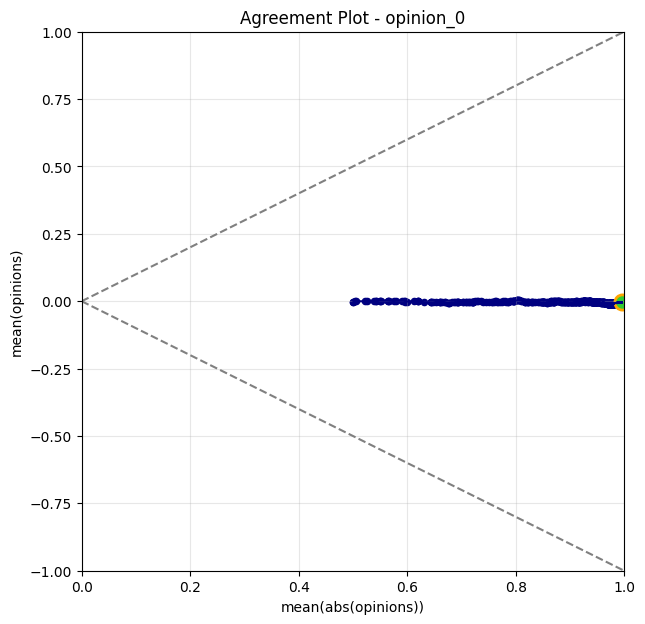

In [4]:
max_opinion_id = int(str(agents.columns[-1])[-1])
last_opinion = max_opinion_id+0

for opinion_id in range(0,last_opinion):
    opinion_col :str = f"opinion_{opinion_id}"
    
    cleaned = agents[agents["agent_id"]>0]
    # print(cleaned)
    
    df = cleaned[["step", opinion_col]].copy()
    df["abs_opinion"] = df[opinion_col].abs()
    
    # print(df[df["step"]==2][opinion_col].mean())
    # print(df[df["step"]==2]["abs_opinion"].mean())
    
    mean = df.groupby("step")[opinion_col].mean()
    abs_mean = df.groupby("step")["abs_opinion"].mean()
    
    # print(mean)
    # print(abs_mean)
    
    agreement = pd.DataFrame()
    agreement["mean_abs"] = abs_mean
    agreement["mean_opinion"] = mean
    agreement = agreement.reset_index()
   
    # print(agreement)
    draw_agree(agreement)

# Spread Opinions

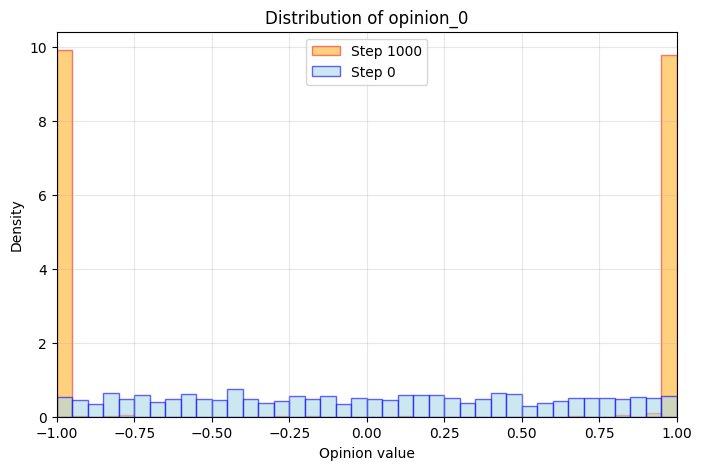

In [5]:
cleaned = agents[agents["agent_id"]>0]

last_step_value = agents["step"].iloc[-1]
last_step = cleaned[cleaned["step"]==last_step_value]
first_step = cleaned[cleaned["step"] == 0]


for opinion_id in range(0,last_opinion):
    opinion_col :str = f"opinion_{opinion_id}"
    
    df_last = last_step[opinion_col].copy()
    df_first = first_step[opinion_col].copy()
    
    plt.figure(figsize=(8, 5))

    # Histogram (normalized so it matches KDE scale)
    plt.hist(
        df_last,
        bins=40,
        range=(-1, 1),
        density=True,
        alpha=0.5,
        edgecolor="red",
        color="orange",
        label=f"Step {last_step_value}"
    )
    plt.hist(
        df_first,
        bins=40,
        range=(-1, 1),
        density=True,
        alpha=0.6,
        edgecolor="blue",
        color="lightblue",
        label="Step 0"
    )
    
    # # KDE curve
    # x = np.linspace(-1, 1, 500)
    # kde_first = gaussian_kde(df_first, bw_method=0.1)
    # plt.plot(x, kde_first(x), color="blue")

    # kde_last = gaussian_kde(df_last, bw_method=0.1)
    # plt.plot(x, kde_last(x), color="red")
        
    plt.xlim(-1, 1)
    plt.xlabel("Opinion value")
    plt.ylabel("Density")
    plt.title(f"Distribution of {opinion_col}")
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.show()


# print(last_step.iloc[-1])

# Agent Opinion Evolution

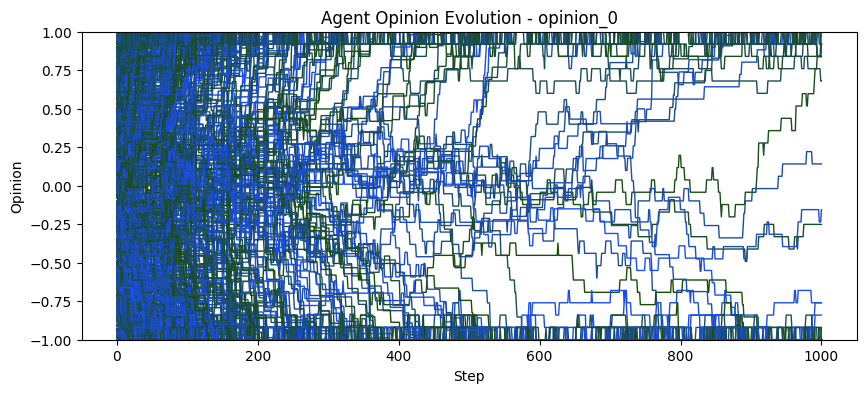

In [6]:
for opinion_id in range(0, last_opinion):
    opinion_col = f"opinion_{opinion_id}"

    plt.figure(figsize=(10, 4))

    # Draw one line per agent
    for agent_id in cleaned["agent_id"].unique():
        agent_data = cleaned[cleaned["agent_id"] == agent_id]
        plt.plot(
            agent_data["step"],
            agent_data[opinion_col],
            linewidth=1,
            alpha=1,
            color=(0.1,0.3,random.random()/1.0 )
        )

    plt.xlabel("Step")
    plt.ylabel("Opinion")
    plt.title(f"Agent Opinion Evolution - {opinion_col}")
    plt.ylim(-1, 1)
    plt.show()

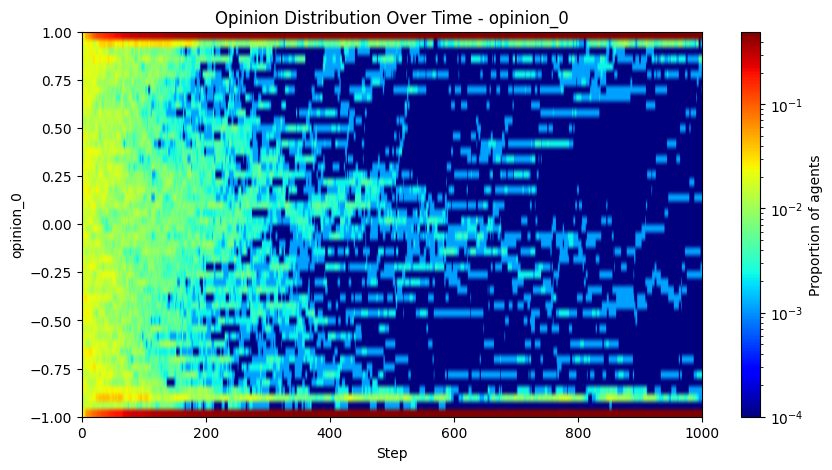

In [7]:
num_y_bins = 50
y_bins = np.linspace(-1, 1, num_y_bins + 1)

for opinion_id in range(0, last_opinion):
    opinion_col = f"opinion_{opinion_id}"

    steps = sorted(cleaned["step"].unique())
    heatmap = []

    for step in steps:
        step_data = cleaned[cleaned["step"] == step]
        opinions = step_data[opinion_col].dropna()

        counts, _ = np.histogram(opinions, bins=y_bins)

        if len(opinions) > 0:
            counts = counts / len(opinions)

        heatmap.append(counts)

    heatmap = np.array(heatmap).T

    plt.figure(figsize=(10, 5))
    # plt.imshow(
    #     heatmap,
    #     aspect="auto",
    #     origin="lower",
    #     extent=[min(steps), max(steps), -1, 1],
    #     cmap="turbo",
    #     # cmap="Greys",
    #     vmin=0,
    #     vmax=heatmap.max()
    # )

    # plt.colorbar(label="Proportion of agents")
    # plt.xlabel("Step")
    # plt.ylabel(opinion_col)
    # plt.title(f"Opinion Distribution Over Time - {opinion_col}")
    # plt.show()
    
    heatmap[heatmap == 0] = 1e-6
    plt.imshow(
        heatmap,
        aspect="auto",
        origin="lower",
        extent=[min(steps), max(steps), -1, 1],
        # cmap="turbo",
        # cmap="Greys",
        # cmap="viridis",
        cmap="jet",
        norm=LogNorm(
            # vmin=1e-3,  
            # vmin=5e-3,
            vmin=1e-4, 
            vmax=heatmap.max()
        )
    )

    plt.colorbar(label="Proportion of agents")
    plt.xlabel("Step")
    plt.ylabel(opinion_col)
    plt.title(f"Opinion Distribution Over Time - {opinion_col}")
    plt.show()

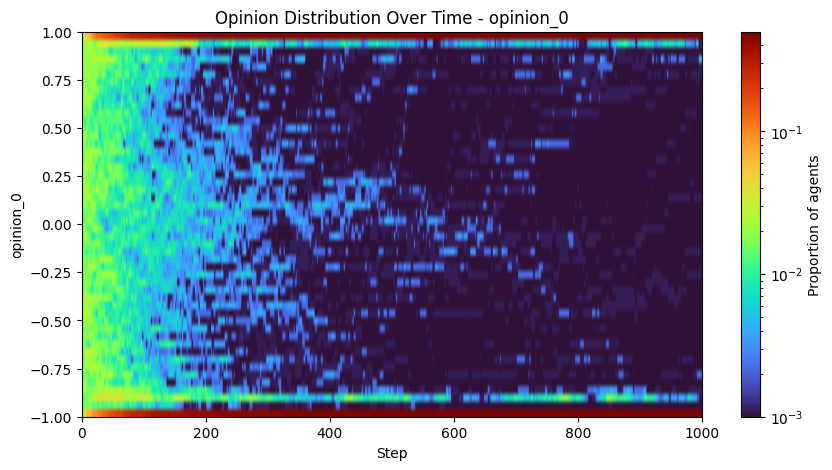

In [8]:
for opinion_id in range(0, last_opinion):
    opinion_col = f"opinion_{opinion_id}"

    steps = sorted(cleaned["step"].unique())
    heatmap = []

    for step in steps:
        step_data = cleaned[cleaned["step"] == step]
        opinions = step_data[opinion_col].dropna()

        counts, _ = np.histogram(opinions, bins=y_bins)

        if len(opinions) > 0:
            counts = counts / len(opinions)

        heatmap.append(counts)

    heatmap = np.array(heatmap).T

    plt.figure(figsize=(10, 5))
    
    heatmap[heatmap == 0] = 1e-6
    plt.imshow(
        heatmap,
        aspect="auto",
        origin="lower",
        extent=[min(steps), max(steps), -1, 1],
        cmap="turbo",
        # cmap="Greys",
        # cmap="viridis",
        norm=LogNorm(
            vmin=1e-3,  
            # vmin=5e-3,
            # vmin=1e-4, 
            vmax=heatmap.max()
        )
    )

    plt.colorbar(label="Proportion of agents")
    plt.xlabel("Step")
    plt.ylabel(opinion_col)
    plt.title(f"Opinion Distribution Over Time - {opinion_col}")
    plt.show()